In [1]:
from math import ceil
from joblib import Memory
from datetime import timedelta
import pickle
import hashlib
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from mmocc.config import (
    fig_column_width,
    fig_page_width,
    golden_ratio,
    silver_ratio,
    bronze_ratio,
    default_image_backbone,
    default_sat_backbone,
    figures_path,
    image_feature_dims,
    sat_feature_dims,
    cache_path,
)
from mmocc.plot_utils import setup_matplotlib
from mmocc.train_utils import img_model_labels, sat_model_labels
from mmocc.utils import (
    get_focal_species_ids,
    powerset,
    experiment_to_filename,
    get_scientific_taxon_map,
)

setup_matplotlib()

# disable jax pre-allocation
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = ""

figures_dir = str(figures_path)
os.makedirs(figures_dir, exist_ok=True)
use_nonlinear_regressors = False

memory = Memory(cache_path / "joblib_figures")
memory.reduce_size(age_limit=timedelta(days=30))


@memory.cache
def load_df(experiment_paths):
    df = []
    for filepath, _ in tqdm(experiment_paths):
        with open(filepath, "rb") as f:
            data = pickle.load(f)
            del data["mcmc_samples"]  # dont need to keep this in df
            df.append(data)

    df = pd.DataFrame(df)

    return df

In [ ]:
from pathlib import Path
from datetime import datetime, timezone

FIT_ROOTS = [
    cache_path / "fit_results",
    Path("/data/vision/beery/cachange/mmocc_og/cache/fit_results"),
]

DF_CACHE_PATH = cache_path / "figure_data_habitat_refit.pkl"
REBUILD_DF = True # False

enable_cache_busting = True


def _fit_dates_from_path(filepath):
    fit_mtime_epoch = filepath.stat().st_mtime
    fit_timestamp_utc = datetime.fromtimestamp(fit_mtime_epoch, tz=timezone.utc)
    fit_date_local = fit_timestamp_utc.astimezone().date().isoformat()
    return fit_mtime_epoch, fit_timestamp_utc.isoformat(), fit_date_local


def _modalities_set(modalities):
    if isinstance(modalities, str):
        return {m.strip() for m in modalities.split(",") if m.strip()}
    if modalities is None:
        return set()
    return set(modalities)


def refit_experiment_to_filename(
    taxon_id,
    modalities,
    gl_backbone_name,
    habitat_gl_backbone,
    rs_backbone_name,
    habitat_rs_backbone,
    suffix=None,
):
    modalities_str = "_".join(sorted(modalities))
    filename = (
        f"{taxon_id}_refit_modalities_{modalities_str}"
        f"_gl_{gl_backbone_name}"
        f"_habitat_gl_{habitat_gl_backbone}"
        f"_rs_{rs_backbone_name}"
        f"_habitat_rs_{habitat_rs_backbone}"
    )
    if suffix is not None:
        filename += f".{suffix}"
    return filename


def _resolve_path(spec, taxon_id):
    refit_filename = refit_experiment_to_filename(
        taxon_id,
        spec["modalities"],
        spec["gl_backbone"],
        spec["habitat_gl_backbone"],
        spec["rs_backbone"],
        spec["habitat_rs_backbone"],
        "pkl",
    )
    for root in FIT_ROOTS:
        candidate = root / refit_filename
        if candidate.exists():
            return candidate, "refit", root

    legacy_habitat_gl_backbone = spec.get("legacy_fallback_habitat_gl")
    if legacy_habitat_gl_backbone is not None:
        legacy_filename = experiment_to_filename(
            taxon_id,
            {"image", "sat", "covariates"},
            legacy_habitat_gl_backbone,
            default_sat_backbone,
            "pkl",
        )
        for root in FIT_ROOTS:
            candidate = root / legacy_filename
            if candidate.exists():
                return candidate, "legacy_fallback", root

    return None, None, None

# TODO: if this grows too large for notebook iteration speed, gate with include_legacy=False.
experiment_specs = [
    {
        "spec_label": "baseline_gl_refit",
        "modalities": {"gl"},
        "gl_backbone": default_image_backbone,
        "habitat_gl_backbone": None,
        "rs_backbone": None,
        "habitat_rs_backbone": None,
        "legacy_fallback_habitat_gl": None,
    },
    {
        "spec_label": "habitat_gl_visdiff",
        "modalities": {"habitat_gl"},
        "gl_backbone": None,
        "habitat_gl_backbone": "visdiff_clip",
        "rs_backbone": None,
        "habitat_rs_backbone": None,
        "legacy_fallback_habitat_gl": "visdiff_clip",
    },
    {
        "spec_label": "habitat_gl_plus_gl_visdiff",
        "modalities": {"habitat_gl", "gl"},
        "gl_backbone": default_image_backbone,
        "habitat_gl_backbone": "visdiff_clip",
        "rs_backbone": None,
        "habitat_rs_backbone": None,
        "legacy_fallback_habitat_gl": None,
    },
    {
        "spec_label": "habitat_gl_plus_env_visdiff",
        "modalities": {"habitat_gl", "env"},
        "gl_backbone": None,
        "habitat_gl_backbone": "visdiff_clip",
        "rs_backbone": None,
        "habitat_rs_backbone": None,
        "legacy_fallback_habitat_gl": None,
    },
    {
        "spec_label": "habitat_gl_plus_gl_rs_env_visdiff",
        "modalities": {"habitat_gl", "gl", "rs", "env"},
        "gl_backbone": default_image_backbone,
        "habitat_gl_backbone": "visdiff_clip",
        "rs_backbone": default_sat_backbone,
        "habitat_rs_backbone": None,
        "legacy_fallback_habitat_gl": None,
    },
]

legacy_image_backbones = sorted(list(image_feature_dims.keys()))
legacy_sat_backbones = sorted(list(sat_feature_dims.keys()))
legacy_modalities = ["image", "sat", "covariates"]
legacy_modalities_subsets = [set(m) for m in powerset(legacy_modalities) if len(m) > 0]


def _legacy_spec_label(modalities_subset, image_backbone, sat_backbone):
    modalities_str = "_".join(sorted(modalities_subset))
    return (
        f"legacy_{modalities_str}_"
        f"image_{image_backbone}_sat_{sat_backbone}"
    )


def _make_record(
    *,
    taxon_id,
    spec_label,
    filepath,
    source_kind,
    fit_root,
    enable_cache_busting,
):
    if enable_cache_busting:
        with open(filepath, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
    else:
        file_hash = None

    fit_mtime_epoch, fit_timestamp_utc, fit_date_local = _fit_dates_from_path(filepath)
    return {
        "taxon_id": taxon_id,
        "spec_label": spec_label,
        "filepath": filepath,
        "hash": file_hash,
        "source_kind": source_kind,
        "fit_root": str(fit_root),
        "fit_mtime_epoch": fit_mtime_epoch,
        "fit_timestamp_utc": fit_timestamp_utc,
        "fit_date_local": fit_date_local,
    }


def build_legacy_experiment_records(enable_cache_busting=True):
    records = []
    for taxon_id in get_focal_species_ids():
        for modalities_subset in legacy_modalities_subsets:
            modality_image_backbones = (
                legacy_image_backbones if "image" in modalities_subset else [None]
            )
            modality_sat_backbones = (
                legacy_sat_backbones if "sat" in modalities_subset else [None]
            )
            for image_backbone in modality_image_backbones:
                for sat_backbone in modality_sat_backbones:
                    if (
                        image_backbone is not None
                        and image_backbone != default_image_backbone
                    ) and (
                        sat_backbone is not None
                        and sat_backbone != default_sat_backbone
                    ):
                        continue

                    filename = experiment_to_filename(
                        taxon_id,
                        modalities_subset,
                        image_backbone,
                        sat_backbone,
                        "pkl",
                    )

                    filepath = None
                    fit_root = None
                    for root in FIT_ROOTS:
                        candidate = root / filename
                        if candidate.exists():
                            filepath = candidate
                            fit_root = root
                            break

                    if filepath is None or fit_root is None:
                        continue

                    records.append(
                        _make_record(
                            taxon_id=taxon_id,
                            spec_label=_legacy_spec_label(
                                modalities_subset, image_backbone, sat_backbone
                            ),
                            filepath=filepath,
                            source_kind="legacy_scan",
                            fit_root=fit_root,
                            enable_cache_busting=enable_cache_busting,
                        )
                    )

    return records


def build_experiment_records(enable_cache_busting=True, include_legacy=True):
    records = []
    for taxon_id in get_focal_species_ids():
        for spec in experiment_specs:
            filepath, source_kind, fit_root = _resolve_path(spec, taxon_id)
            if filepath is None:
                print(
                    f"Skipping missing experiment for taxon_id={taxon_id}, spec={spec['spec_label']}"
                )
                continue

            records.append(
                _make_record(
                    taxon_id=taxon_id,
                    spec_label=spec["spec_label"],
                    filepath=filepath,
                    source_kind=source_kind,
                    fit_root=fit_root,
                    enable_cache_busting=enable_cache_busting,
                )
            )

    if include_legacy:
        records.extend(build_legacy_experiment_records(enable_cache_busting))

    return records


# TODO: Prefer explicit fit_timestamp_utc saved in each fit_results pickle when available.
# NOTE: fit_timestamp_utc / fit_date_local are currently mtime-derived fallbacks.
# If fit-result files are copied or touched, filesystem mtime may drift from true fit time.
@memory.cache
def load_df(experiment_records):
    rows = []
    for record in tqdm(experiment_records):
        with open(record["filepath"], "rb") as f:
            data = pickle.load(f)
        data.pop("mcmc_samples", None)
        data["analysis_spec"] = record["spec_label"]
        data["source_kind"] = record["source_kind"]
        data["fit_root"] = record["fit_root"]
        data["fit_path"] = str(record["filepath"])
        data["fit_mtime_epoch"] = record["fit_mtime_epoch"]
        data["fit_timestamp_utc"] = record["fit_timestamp_utc"]
        data["fit_date_local"] = record["fit_date_local"]
        rows.append(data)

    return pd.DataFrame(rows)


if REBUILD_DF or not DF_CACHE_PATH.exists():
    experiment_records = build_experiment_records(enable_cache_busting)
    df = load_df(experiment_records)
    df.to_pickle(DF_CACHE_PATH)
else:
    df = pd.read_pickle(DF_CACHE_PATH)

if "analysis_spec" not in df.columns:
    raise ValueError(
        "Loaded dataframe does not include refit analysis metadata. Set REBUILD_DF=True once."
    )

df["modalities_set"] = df["modalities"].apply(_modalities_set)
df["lppd_test_norm"] = (df["lppd_test"] - df["lppd_null_test"]) / (
    df["lppd_oracle_test"] - df["lppd_null_test"]
)
df_raw = df.copy()

print(df.groupby(["analysis_spec", "source_kind"]).size())
df.head()

________________________________________________________________________________
[Memory] Calling __main__--tmp-ipykernel-1644798848.load_df...
load_df([ { 'filepath': PosixPath('/data/vision/beery/cachange/mmocc_og/cache/fit_results/00804e75-09ef-44e5-8984-85e365377d47_refit_modalities_gl_gl_dinov2_vitb14_habitat_gl_None_rs_None_habitat_rs_None.pkl'),
    'fit_root': '/data/vision/beery/cachange/mmocc_og/cache/fit_results',
    'hash': 'a4320564997dda02009101b8bc4cccc0',
    'source_kind': 'refit',
    'spec_label': 'baseline_gl_refit',
    'taxon_id': '00804e75-09ef-44e5-8984-85e365377d47'},
  { 'filepath': PosixPath('/data/vision/beery/cachange/mmocc_og/cache/fit_results/00804e75-09ef-44e5-8984-85e365377d47_refit_modalities_habitat_gl_gl_None_habitat_gl_visdiff_clip_rs_None_habitat_rs_None.pkl'),
    'fit_root': '/data/vision/beery/cacha...)


  0%|          | 0/54 [00:00<?, ?it/s]

_______________________________________________________load_df - 982.2s, 16.4min
analysis_spec       source_kind
baseline_gl_refit   refit          27
habitat_gl_visdiff  refit          27
dtype: int64


,taxon_id,scientific_name,common_name,modalities,image_backbone,sat_backbone,gl_backbone,habitat_gl_backbone,rs_backbone,habitat_rs_backbone,...,biolith_roc_auc_oracle_train,biolith_roc_auc_oracle_test,biolith_errors,best_params,analysis_spec,source_kind,fit_root,fit_path,modalities_set,lppd_test_norm
0,00804e75-09ef-44e5-8984-85e365377d47,Antilocapra americana,pronghorn,[gl],dinov2_vitb14,None,dinov2_vitb14,NaN,None,None,...,NaN,1.000000,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{gl},0.124796
1,00804e75-09ef-44e5-8984-85e365377d47,Antilocapra americana,pronghorn,[habitat_gl],visdiff_clip,None,NaN,visdiff_clip,None,None,...,NaN,1.000000,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{habitat_gl},2.360786
2,07843615-e1fc-49d8-9821-fd1d7ff2e773,Dasypus novemcinctus,nine-banded armadillo,[gl],dinov2_vitb14,None,dinov2_vitb14,NaN,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{gl},-0.077168
3,07843615-e1fc-49d8-9821-fd1d7ff2e773,Dasypus novemcinctus,nine-banded armadillo,[habitat_gl],visdiff_clip,None,NaN,visdiff_clip,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{habitat_gl},-0.093018
4,0f2e2c41-f1bb-4cdd-8e97-ba7cffba3e86,Lepus americanus,snowshoe hare,[gl],dinov2_vitb14,None,dinov2_vitb14,NaN,None,None,...,NaN,1.000000,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{gl},0.260678
5,0f2e2c41-f1bb-4cdd-8e97-ba7cffba3e86,Lepus americanus,snowshoe hare,[habitat_gl],visdiff_clip,None,NaN,visdiff_clip,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{habitat_gl},0.096004
6,16ec4010-f175-4de7-8a99-85aadec3963b,Sciurus griseus,western gray squirrel,[gl],dinov2_vitb14,None,dinov2_vitb14,NaN,None,None,...,NaN,1.000000,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{gl},0.080874
7,16ec4010-f175-4de7-8a99-85aadec3963b,Sciurus griseus,western gray squirrel,[habitat_gl],visdiff_clip,None,NaN,visdiff_clip,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{habitat_gl},0.136091
8,1db1c6e2-2ea9-45a6-ab69-a730133298eb,Tamias striatus,eastern chipmunk,[gl],dinov2_vitb14,None,dinov2_vitb14,NaN,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{gl},0.408551
9,1db1c6e2-2ea9-45a6-ab69-a730133298eb,Tamias striatus,eastern chipmunk,[habitat_gl],visdiff_clip,None,NaN,visdiff_clip,None,None,...,NaN,1.000000,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{habitat_gl},0.324769


In [2]:
path =  figures_path / "habitat_refit_results.csv"
if path.exists():
    print('reading from csv')
    df = pd.read_csv(path)
else:
    df.to_csv(figures_path / "habitat_refit_results.csv", index=False)

reading from csv


In [3]:
df.head()

,taxon_id,scientific_name,common_name,modalities,image_backbone,sat_backbone,gl_backbone,habitat_gl_backbone,rs_backbone,habitat_rs_backbone,...,biolith_roc_auc_oracle_train,biolith_roc_auc_oracle_test,biolith_errors,best_params,analysis_spec,source_kind,fit_root,fit_path,modalities_set,lppd_test_norm
0,00804e75-09ef-44e5-8984-85e365377d47,Antilocapra americana,pronghorn,['gl'],dinov2_vitb14,NaN,dinov2_vitb14,NaN,NaN,NaN,...,NaN,1.0,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{'gl'},0.124796
1,00804e75-09ef-44e5-8984-85e365377d47,Antilocapra americana,pronghorn,['habitat_gl'],visdiff_clip,NaN,NaN,visdiff_clip,NaN,NaN,...,NaN,1.0,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{'habitat_gl'},2.360786
2,07843615-e1fc-49d8-9821-fd1d7ff2e773,Dasypus novemcinctus,nine-banded armadillo,['gl'],dinov2_vitb14,NaN,dinov2_vitb14,NaN,NaN,NaN,...,NaN,1.0,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{'gl'},-0.077168
3,07843615-e1fc-49d8-9821-fd1d7ff2e773,Dasypus novemcinctus,nine-banded armadillo,['habitat_gl'],visdiff_clip,NaN,NaN,visdiff_clip,NaN,NaN,...,NaN,1.0,[],"{'prior_type': 'normal', 'occ_params': {'loc':...",habitat_gl_visdiff,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{'habitat_gl'},-0.093018
4,0f2e2c41-f1bb-4cdd-8e97-ba7cffba3e86,Lepus americanus,snowshoe hare,['gl'],dinov2_vitb14,NaN,dinov2_vitb14,NaN,NaN,NaN,...,NaN,1.0,[],"{'prior_type': 'laplace', 'occ_params': {'loc'...",baseline_gl_refit,refit,/data/vision/beery/cachange/mmocc_og/cache/fit...,/data/vision/beery/cachange/mmocc_og/cache/fit...,{'gl'},0.260678


In [ ]:
df.fit_path.iloc[0]
#TODO: /data/vision/beery/scratch/timm/multimodal_occupancy/.cache/figure_data_refit_graft.pkl

'/data/vision/beery/cachange/mmocc_og/cache/fit_results/00804e75-09ef-44e5-8984-85e365377d47_refit_modalities_gl_gl_dinov2_vitb14_habitat_gl_None_rs_None_habitat_rs_None.pkl'

In [3]:
min_occupancy = 0.1  # TODO
low_occupancy_mask = df["mean_naive_occupancy_test"] < min_occupancy
print(
    f"Removing {df[low_occupancy_mask]['taxon_id'].nunique()} species with low occupancy (< 0.1)"
)
df = df[df["mean_naive_occupancy_test"] >= min_occupancy]

Removing 9 species with low occupancy (< 0.1)


### Compare Habitat-Only Refit Performance Against GL Baseline

Benchmark the `habitat_gl` VisDiff refits against the split `gl` refit baseline.


In [11]:
comparison_metrics = [
    "lppd_test_norm",
    "biolith_ap_test",
    "biolith_roc_auc_test",
    "lr_map_test",
    "lr_mcc_test",
]

SOURCE_PRIORITY = {
    "refit": 0,
    "legacy_fallback": 1,
}


def align_spec(spec_label: str) -> pd.DataFrame:
    subset = df[df["analysis_spec"] == spec_label].copy()
    if subset.empty:
        return pd.DataFrame(columns=["scientific_name", *comparison_metrics])

    subset["source_priority"] = subset["source_kind"].map(SOURCE_PRIORITY).fillna(99)
    subset = subset.sort_values(
        ["taxon_id", "source_priority", "fit_root", "fit_path"]
    ).drop_duplicates(subset=["taxon_id"], keep="first")

    return subset.set_index("taxon_id")[
        ["scientific_name", *comparison_metrics, "source_kind", "fit_path"]
    ]


baseline_df = align_spec("baseline_gl_refit")
visdiff_df = align_spec("habitat_gl_visdiff")


def summarize_against_baseline(target: pd.DataFrame, label: str) -> pd.DataFrame:
    overlap = baseline_df.index.intersection(target.index)
    merged = (
        baseline_df.loc[overlap, comparison_metrics]
        .add_suffix("_baseline")
        .join(target.loc[overlap, comparison_metrics].add_suffix(f"_{label}"))
    )

    rows = []
    for metric in comparison_metrics:
        deltas = merged[f"{metric}_{label}"] - merged[f"{metric}_baseline"]
        rows.append(
            {
                "metric": metric,
                "n_species": len(deltas),
                "mean_delta": deltas.mean(),
                "median_delta": deltas.median(),
                "improved_%": 100 * (deltas > 0).mean(),
            }
        )
    return pd.DataFrame(rows)


visdiff_vs_baseline = summarize_against_baseline(visdiff_df, "visdiff")

print(
    f"Baseline species={len(baseline_df)}, target species={len(visdiff_df)}, overlap={len(baseline_df.index.intersection(visdiff_df.index))}"
)
print(
    "Target source kinds:",
    df[df["analysis_spec"] == "habitat_gl_visdiff"]["source_kind"].value_counts().to_dict(),
)

visdiff_vs_baseline.round(3)


Baseline species=27, target species=27, overlap=27
Target source kinds: {'refit': 27}


,metric,n_species,mean_delta,median_delta,improved_%
0,lppd_test_norm,27,0.966,-0.028,37.037
1,biolith_ap_test,27,-0.050,-0.049,11.111
2,biolith_roc_auc_test,27,-0.046,-0.046,25.926
3,lr_map_test,27,-0.042,-0.040,22.222
4,lr_mcc_test,27,-0.053,0.000,18.519


In [22]:
import numpy as np
import pandas as pd

# 1) normalize modality label
work = df.copy()
work["modality_label"] = work["modalities"].apply(
    lambda m: "+".join(sorted(m)) if isinstance(m, (list, set, tuple)) else str(m)
)

# 2) choose metrics (edit as needed)
metrics = [
    "lppd_test_norm",
    "biolith_ap_test",
    "biolith_roc_auc_test",
    "lr_map_test",
    "lr_mcc_test",
]

# keep only metrics that exist
metrics = [m for m in metrics if m in work.columns]

# 3) per-species average per modality
per_species = (
    work.groupby(["modality_label", "taxon_id"], as_index=False)[metrics]
    .mean(numeric_only=True)
)

# 4) per-modality summary of species means
per_modality = (
    per_species.groupby("modality_label")[metrics]
    .agg(["mean", "median", "std", "count"])
    .sort_index()
)

per_species.head(), per_modality


(  modality_label                              taxon_id  lppd_test_norm  \
 0             gl  00804e75-09ef-44e5-8984-85e365377d47        0.124796   
 1             gl  07843615-e1fc-49d8-9821-fd1d7ff2e773       -0.077168   
 2             gl  0f2e2c41-f1bb-4cdd-8e97-ba7cffba3e86        0.260678   
 3             gl  16ec4010-f175-4de7-8a99-85aadec3963b        0.080874   
 4             gl  1db1c6e2-2ea9-45a6-ab69-a730133298eb        0.408551   
 
    biolith_ap_test  biolith_roc_auc_test  lr_map_test  lr_mcc_test  
 0         0.309620              0.839669     0.245689     0.141672  
 1         0.382312              0.612738     0.393067     0.033787  
 2         0.179037              0.736930     0.178220     0.164879  
 3         0.227707              0.626551     0.253552     0.000000  
 4         0.311676              0.744946     0.369126     0.000000  ,
                lppd_test_norm                           biolith_ap_test  \
                          mean    median       std 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["modality_label"] = plot_df["modalities"].apply(
    lambda m: "+".join(sorted(m)) if isinstance(m, (list, set, tuple)) else str(m)
)

metric = "log(lppd_test_norm)"

# optional: simplify species labels
plot_df["species_label"] = plot_df["scientific_name"].fillna(plot_df["taxon_id"])

g = sns.catplot(
    data=plot_df,
    kind="bar",
    x="species_label",
    y=metric,
    hue="modality_label",   # grouped by modality
    col="source_kind",      # optional split: refit vs legacy_fallback
    col_wrap=1,
    height=5,
    aspect=3,
    estimator="mean",
    errorbar=None,
    dodge=True
)

for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Species")
    ax.set_ylabel("log(lppd_test_norm)")
# for ax in g.axes.flat:
    ax.set_yscale("symlog", linthresh=0.1)  # adjust linthresh as needed

g.fig.tight_layout()
plt.show()


In [23]:
per_modality

lppd_test_norm                           biolith_ap_test  \
                         mean    median       std count            mean   
modality_label                                                            
gl                   1.059075  0.200130  6.363573    27        0.315861   
habitat_gl           2.024628  0.132151  7.762003    27        0.265546   

                                         biolith_roc_auc_test            \
                  median       std count                 mean    median   
modality_label                                                            
gl              0.289674  0.226500    27             0.712521  0.714228   
habitat_gl      0.198898  0.215261    27             0.666923  0.669332   

                               lr_map_test                            \
                     std count        mean    median       std count   
modality_label                                                         
gl              0.091678    27    0.310304  0.261663  0.227992    27   
habitat_gl      0.115070    27    0.268441  0.192274  0.219987    27   

               lr_mcc_test                         
                      mean median       std count  
modality_label                                     
gl                0.071336    0.0  0.123749    27  
habitat_gl        0.018750    0.0  0.061737    27

/tmp/ipykernel_791201/3643636806.py:21: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
/tmp/ipykernel_791201/3643636806.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


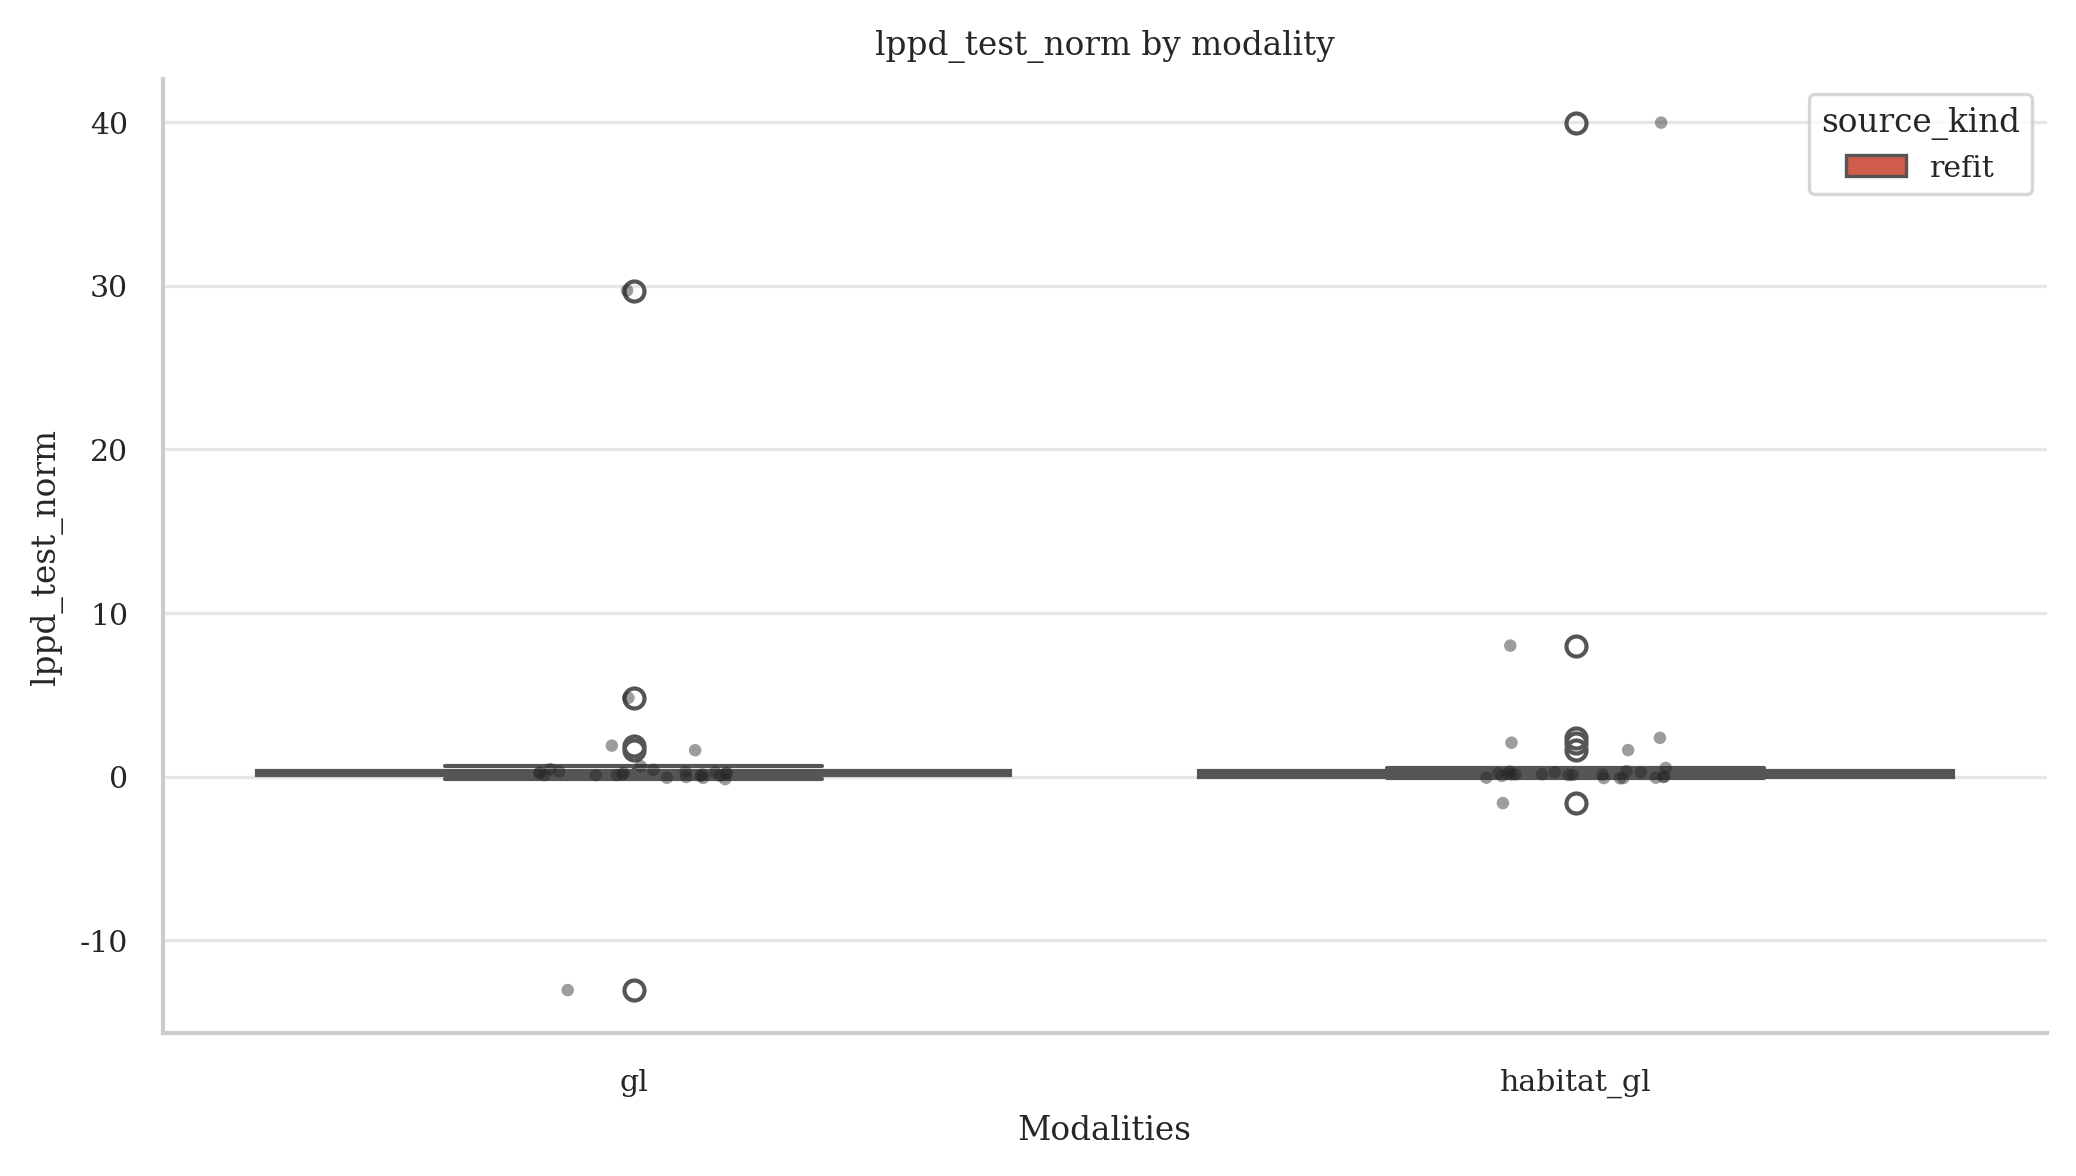

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = df.copy()

# Turn list/set modalities into a clean label like "gl" or "habitat_gl"
plot_df["modality_label"] = plot_df["modalities"].apply(
    lambda m: "+".join(sorted(m)) if isinstance(m, (list, set, tuple)) else str(m)
)

metric = "lppd_test_norm"

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=plot_df,
    x="modality_label",
    y=metric,
    hue="source_kind",   # grouped boxes within each modality
    dodge=True
)
sns.stripplot(
    data=plot_df,
    x="modality_label",
    y=metric,
    hue="source_kind",
    dodge=True,
    alpha=0.45,
    color="black",
    size=3,
    legend=False
)
plt.xlabel("Modalities")
plt.ylabel(metric)
plt.title(f"{metric} by modality")
plt.tight_layout()
plt.show()


In [ ]:
comparison_metrics = [
    "lppd_test_norm",
    "biolith_ap_test",
    "biolith_roc_auc_test",
    "lr_map_test",
    "lr_mcc_test",
]

SOURCE_PRIORITY = {
    "refit": 0,
    "legacy_fallback": 1,
}


def align_spec(spec_label: str) -> pd.DataFrame:
    subset = df[df["analysis_spec"] == spec_label].copy()
    if subset.empty:
        return pd.DataFrame(columns=["scientific_name", *comparison_metrics])

    subset["source_priority"] = subset["source_kind"].map(SOURCE_PRIORITY).fillna(99)
    subset = subset.sort_values(
        ["taxon_id", "source_priority", "fit_root", "fit_path"]
    ).drop_duplicates(subset=["taxon_id"], keep="first")

    return subset.set_index("taxon_id")[
        ["scientific_name", *comparison_metrics, "source_kind", "fit_path"]
    ]


baseline_df = align_spec("baseline_gl_refit")
visdiff_df = align_spec("habitat_gl_visdiff")


def summarize_against_baseline(target: pd.DataFrame, label: str) -> pd.DataFrame:
    overlap = baseline_df.index.intersection(target.index)
    merged = (
        baseline_df.loc[overlap, comparison_metrics]
        .add_suffix("_baseline")
        .join(target.loc[overlap, comparison_metrics].add_suffix(f"_{label}"))
    )

    rows = []
    for metric in comparison_metrics:
        deltas = merged[f"{metric}_{label}"] - merged[f"{metric}_baseline"]
        rows.append(
            {
                "metric": metric,
                "n_species": len(deltas),
                "mean_delta": deltas.mean(),
                "median_delta": deltas.median(),
                "improved_%": 100 * (deltas > 0).mean(),
            }
        )
    return pd.DataFrame(rows)


visdiff_vs_baseline = summarize_against_baseline(visdiff_df, "visdiff")

print(
    f"Baseline species={len(baseline_df)}, target species={len(visdiff_df)}, overlap={len(baseline_df.index.intersection(visdiff_df.index))}"
)
print(
    "Target source kinds:",
    df[df["analysis_spec"] == "habitat_gl_visdiff"]["source_kind"].value_counts().to_dict(),
)

visdiff_vs_baseline.round(3)


Baseline species=27, target species=27, overlap=27
Target source kinds: {'refit': 27}


,metric,n_species,mean_delta,median_delta,improved_%
0,lppd_test_norm,27,0.966,-0.028,37.037
1,biolith_ap_test,27,-0.050,-0.049,11.111
2,biolith_roc_auc_test,27,-0.046,-0.046,25.926
3,lr_map_test,27,-0.042,-0.040,22.222
4,lr_mcc_test,27,-0.053,0.000,18.519


/tmp/ipykernel_791201/2456089429.py:62: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


,backbone,scientific_name,delta,baseline,target
49,visdiff,Taxidea taxus,0.015,0.073,0.087
41,visdiff,Meleagris gallopavo,0.005,0.290,0.295
32,visdiff,Spilogale putorius,0.003,0.009,0.012
38,visdiff,Martes americana,-0.001,0.012,0.011
48,visdiff,Sciurus niger,-0.004,0.202,0.198


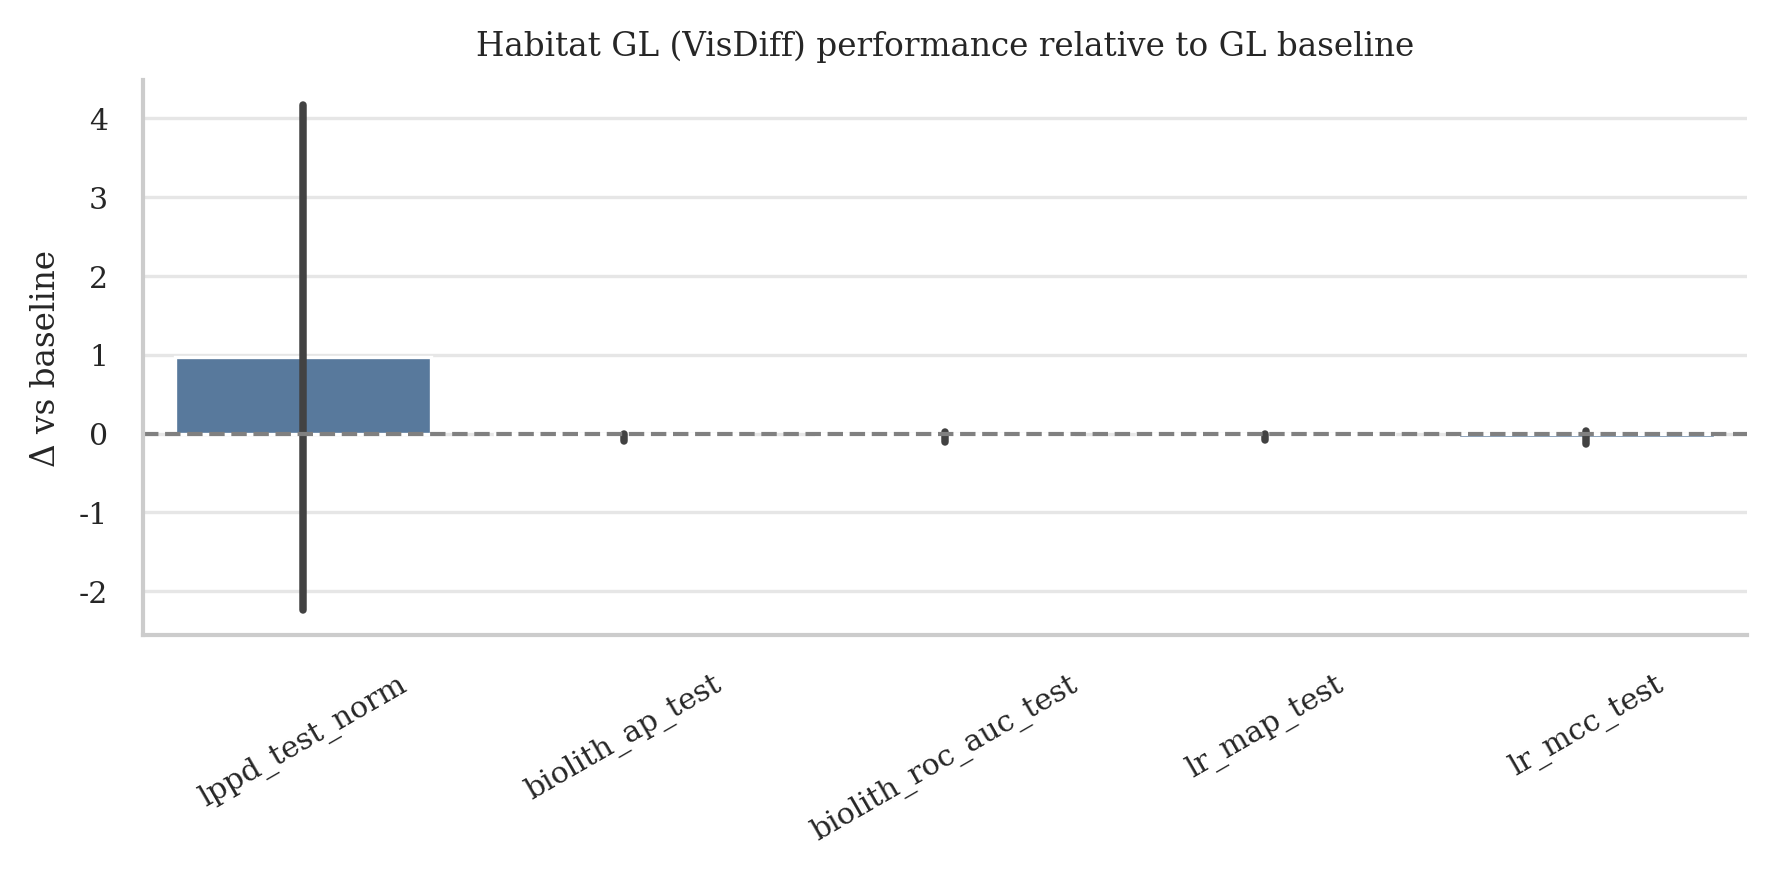

In [12]:
def build_delta_table(target: pd.DataFrame, label: str) -> pd.DataFrame:
    overlap = baseline_df.index.intersection(target.index)
    merged = (
        baseline_df.loc[overlap, ["scientific_name", *comparison_metrics]]
        .rename_axis("taxon_id")
        .join(
            target.loc[overlap, comparison_metrics],
            lsuffix="_baseline",
            rsuffix=f"_{label}",
        )
    )

    records = []
    for metric in comparison_metrics:
        deltas = merged[f"{metric}_{label}"] - merged[f"{metric}_baseline"]
        for taxon_id, delta in deltas.items():
            records.append(
                {
                    "taxon_id": taxon_id,
                    "scientific_name": merged.loc[taxon_id, "scientific_name"],
                    "metric": metric,
                    "backbone": label,
                    "delta": delta,
                    "baseline": merged.loc[taxon_id, f"{metric}_baseline"],
                    "target": merged.loc[taxon_id, f"{metric}_{label}"],
                }
            )
    return pd.DataFrame(records)


delta_long = build_delta_table(visdiff_df, "visdiff")

if delta_long.empty:
    print("No overlapping species available for delta plots.")
    top_improvements = pd.DataFrame(
        columns=["backbone", "scientific_name", "delta", "baseline", "target"]
    )
else:
    subset = delta_long[delta_long["metric"] == "biolith_ap_test"]
    top_improvements = (
        subset.sort_values(["delta"], ascending=False)
        .head(5)
        .assign(backbone="visdiff")
        .loc[:, ["backbone", "scientific_name", "delta", "baseline", "target"]]
    )

    fig, ax = plt.subplots(figsize=(6, 3))
    sns.barplot(
        data=delta_long,
        x="metric",
        y="delta",
        estimator=np.mean,
        errorbar="sd",
        color="#4C78A8",
        ax=ax,
    )
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_ylabel("Δ vs baseline")
    ax.set_xlabel("")
    ax.set_title("Habitat GL (VisDiff) performance relative to GL baseline")
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()


top_improvements.round(3)


/tmp/ipykernel_339159/3674678678.py:38: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
2026-01-22 14:49:43,614 INFO maxp pruned
2026-01-22 14:49:43,619 INFO cmap pruned
2026-01-22 14:49:43,624 INFO kern dropped
2026-01-22 14:49:43,624 INFO post pruned
2026-01-22 14:49:43,625 INFO FFTM dropped
2026-01-22 14:49:43,626 INFO GPOS pruned
2026-01-22 14:49:43,627 INFO GSUB pruned
2026-01-22 14:49:43,629 INFO glyf pruned
2026-01-22 14:49:43,629 INFO Added gid0 to subset
2026-01-22 14:49:43,629 INFO Added first four glyphs to subset
2026-01-22 14:49:43,629 INFO Closing glyph list over 'MATH': 29 glyphs before
2026-01-22 14:49:43,630 INFO Glyph names: ['.notdef', '.null', 'B', 'C', 'D', 'E', 'I', 'L', 'P', 'V', 'a', 'e', 'f', 'four', 'hyphen', 'i', 'l', 'n', 'nonmarkingreturn', 'p', 'period', 'r', 's', 'six', 'space', 't', 'two', 'x', 'zero']
2026-01-22 14:49:43,630 INFO Glyph IDs:   [0, 1, 2, 3, 16, 17, 19, 21, 23, 25, 37, 38, 39, 40, 44, 47, 51, 57, 68, 72, 73, 76, 79

Average improvement in LPPD (normalized): -0.050 (VisDiff), -0.150 (Expert)


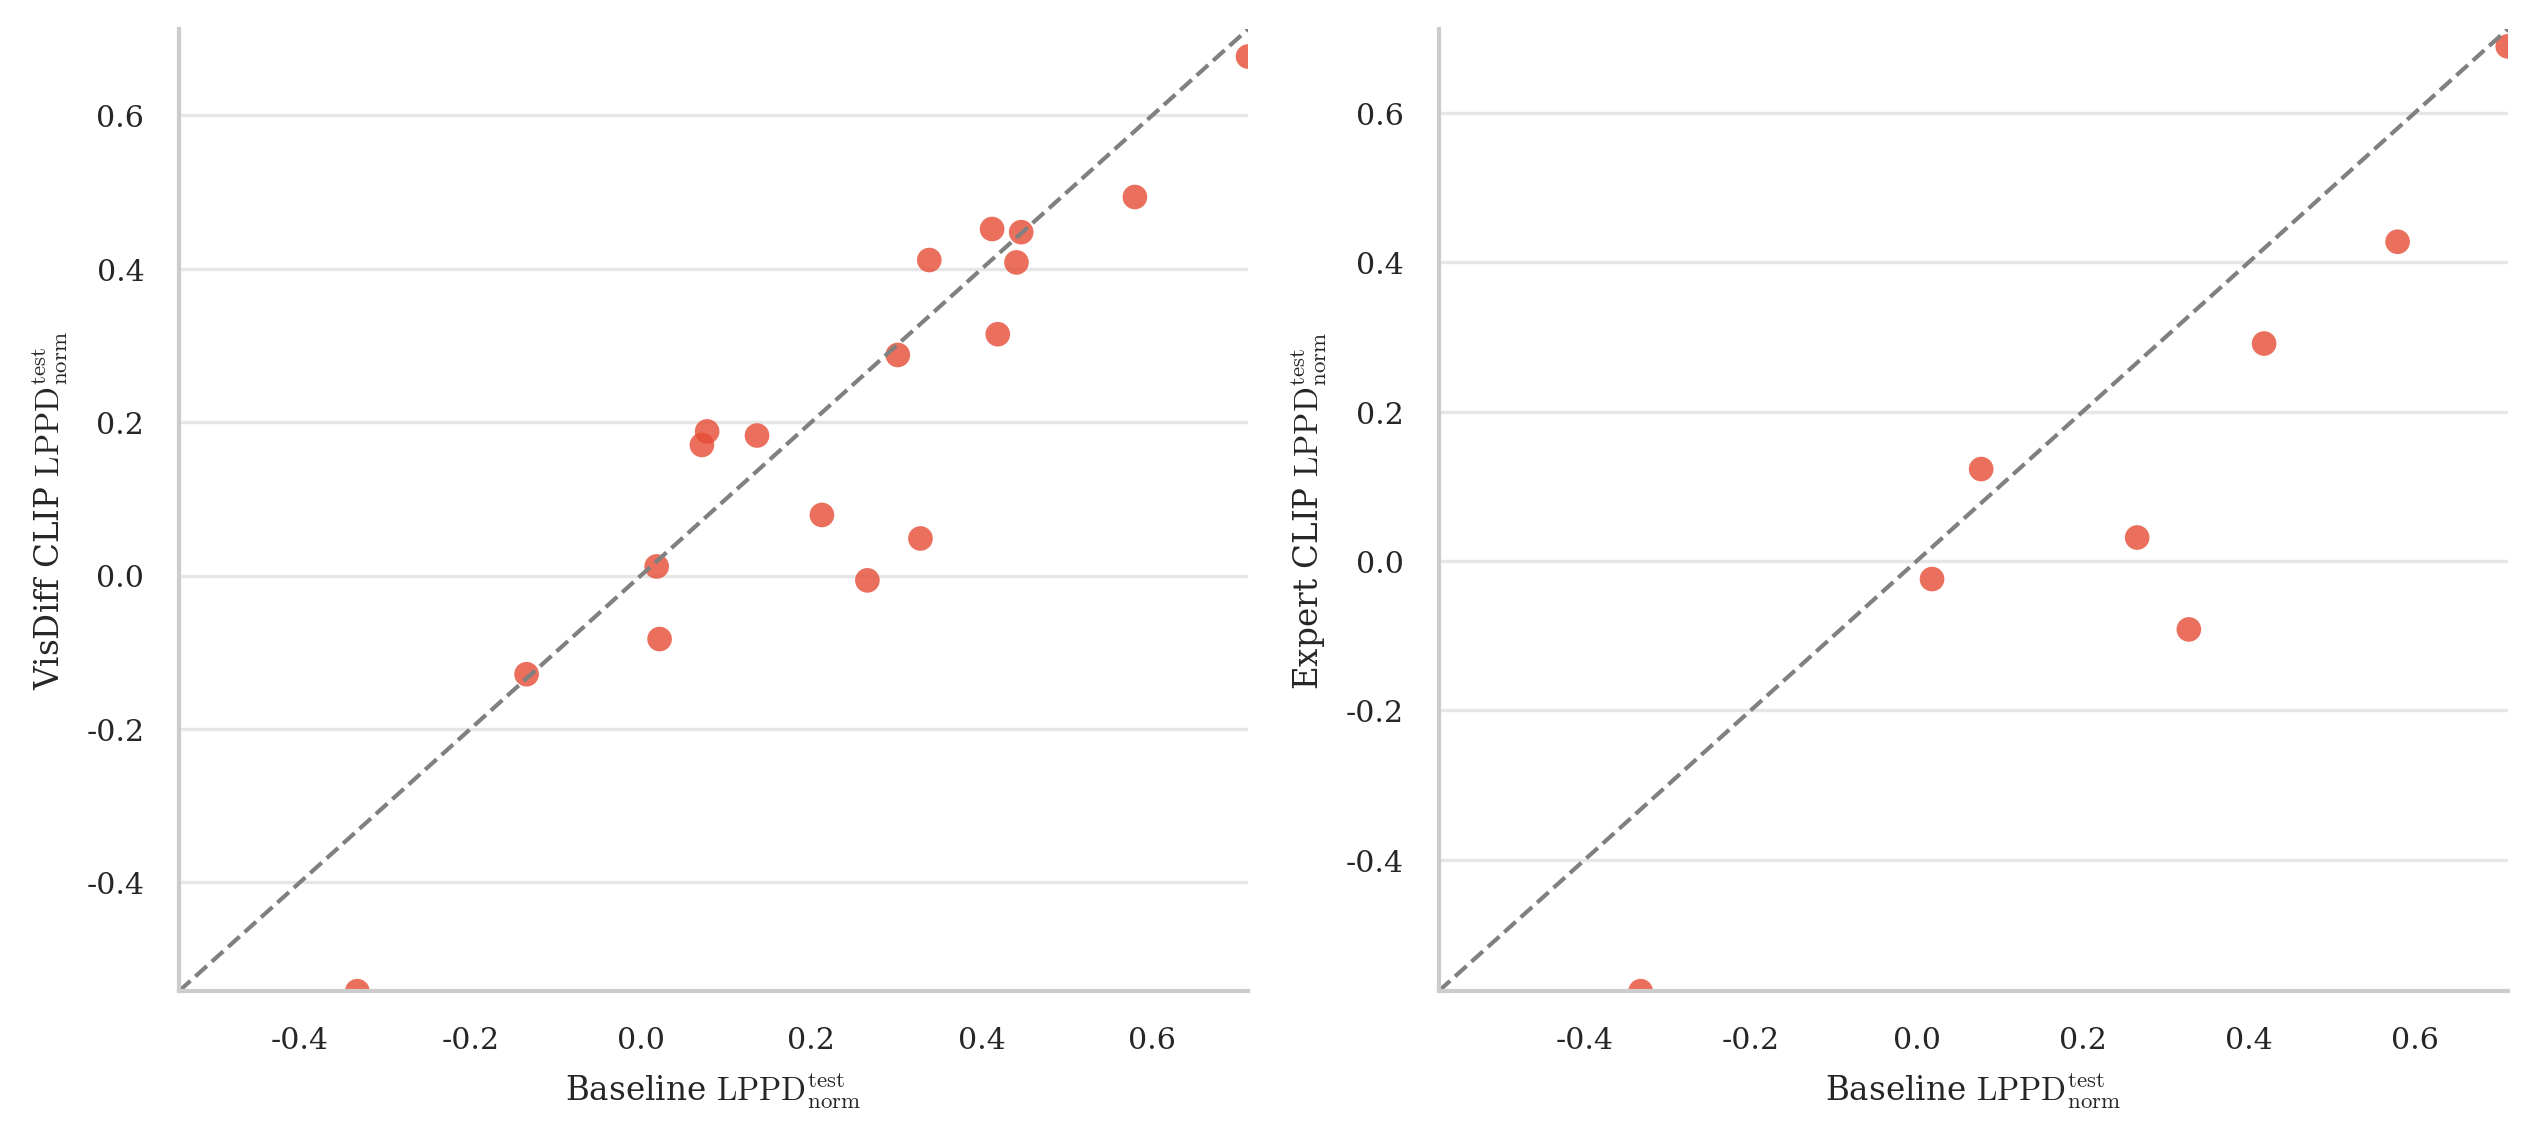

In [6]:
fig, ax = plt.subplots(figsize=(fig_page_width / 2, fig_page_width / 2.3))

overlap = baseline_df.index.intersection(visdiff_df.index)
scatter_data = (
    baseline_df.loc[overlap, ["scientific_name", "lppd_test_norm"]]
    .rename(columns={"lppd_test_norm": "baseline"})
    .join(
        visdiff_df.loc[overlap, ["lppd_test_norm"]].rename(
            columns={"lppd_test_norm": "target"}
        )
    )
)

if not scatter_data.empty:
    ax.scatter(
        scatter_data["baseline"],
        scatter_data["target"],
        s=35,
        alpha=0.8,
        edgecolor="none",
    )

    lims = [
        np.nanmin(scatter_data[["baseline", "target"]].values),
        np.nanmax(scatter_data[["baseline", "target"]].values),
    ]
    ax.plot(lims, lims, linestyle="--", color="gray", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

ax.set_xlabel(r"GL Baseline $\text{LPPD}_\text{norm}^\text{test}$")
ax.set_ylabel(r"Habitat GL VisDiff $\text{LPPD}_\text{norm}^\text{test}$")
fig.tight_layout()
fig.savefig(
    f"{figures_dir}/habitat_gl_refit_lppd_comparison.pdf",
    bbox_inches="tight",
    transparent=True,
)

if not visdiff_vs_baseline.empty:
    mean_delta = visdiff_vs_baseline[
        visdiff_vs_baseline["metric"] == "lppd_test_norm"
    ]["mean_delta"].values[0]
    print(f"Average improvement in normalized LPPD: {mean_delta:.3f} (Habitat GL VisDiff)")
print(f"Scatter overlap species: {len(overlap)}")


In [7]:
df.iloc[df["lppd_test_norm"].argmin()].to_dict()

{'taxon_id': 'febff896-db40-4ac8-bcfe-5bb99a600950',
 'scientific_name': 'Odocoileus hemionus',
 'common_name': 'mule deer',
 'modalities': ['covariates', 'image', 'sat'],
 'image_backbone': 'expert_clip',
 'sat_backbone': 'alphaearth',
 'limit_to_range': True,
 'modalities_scaler': {'covariates': StandardScaler(),
  'image': StandardScaler(),
  'sat': StandardScaler()},
 'modalities_pca': {'covariates': PCA(n_components=26),
  'image': PCA(n_components=5),
  'sat': PCA(n_components=64)},
 'mean_naive_occupancy_train': 0.17104714226115977,
 'mean_naive_occupancy_test': 0.2707948243992606,
 'naive_detection_prob_train': 0.7152495537699985,
 'naive_detection_prob_test': 0.46767153244266274,
 'mean_num_observations_train': 0.17375565610859728,
 'mean_num_observations_test': 0.13896699718810124,
 'mean_num_nonnan_train': 8840,
 'mean_num_nonnan_test': 6757,
 'test_sites_too_close': 1858,
 'lr_mcc_test': -0.32232617712834816,
 'lr_precision_test': 0.0990990990990991,
 'lr_recall_test': 0.15